### Natural Earth Vector Data Source for Urban Area Boundaries

The [Natural Earth Data website](https://www.naturalearthdata.com/downloads/110m-cultural-vectors/) provides a public domain vector geospatial dataset available at a scale of 1:110 million. This dataset includes various cultural and physical geographic features such as:

- Country boundaries  
- Administrative regions  
- Urban areas and populated places  
- Roads and railroads  
- Coastlines and water bodies

These datasets are widely used in geospatial analysis because they are:

- **Open-source and public domain** with free access to shapefiles and GeoJSON data  
- Carefully generalized and aligned for smooth mapping at global to regional scales  
- Complete with feature attributes that support GIS operations and spatial queries  

In this project, the **urban area boundary polygons** from Natural Earth serve as the shapefile input for spatial joins with earthquake epicenter coordinates. This enables the derivation of the **urbanity indicator** feature, which determines whether an earthquake occurred inside an urban area. This feature is critical for calculating risk scores that reflect urban versus rural exposure differences.

Natural Earth data's reliability and ease of integration make it an ideal source for augmenting seismic datasets with important geographic context, especially where official local urban boundary data may be unavailable.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [1]:
# Step 1: Create Urbanity Indicator Using Spatial Join
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

# Convert earthquake DataFrame to GeoDataFrame
df = pd.read_csv('../../../data/preprocessed_earthquake_data_v3.csv')
gdf_points = gpd.GeoDataFrame(
    df, geometry=gpd.points_from_xy(df.longitude, df.latitude), crs="EPSG:4326"
)

# Load urban areas shapefile
urban_areas = gpd.read_file('../../../shp/ne_110m_admin_0_countries.shp')
urban_areas = urban_areas.to_crs(gdf_points.crs)

# Spatial join to check if points lie within urban areas
gdf_joined = gpd.sjoin(gdf_points, urban_areas, how='left', predicate='within')

# Create urbanity indicator: 1 if inside urban area, else 0
gdf_joined['urbanity_indicator'] = gdf_joined['index_right'].notnull().astype(int)

# Check distribution
print(gdf_joined['urbanity_indicator'].value_counts())


urbanity_indicator
0    85444
1    24404
Name: count, dtype: int64


In [3]:
# Step 2: Calculate Urban Risk Score Based on Urbanity Indicator

# Function to compute risk score based on urbanity
def compute_risk_score(row):
  mw = row['Mw']
  depth = max(row['depth'], 1) # Prevent division by zero
  urbanity = row['urbanity_indicator']

  if urbanity == 1: # Urban area
      # Amplified formula for urban areas: higher sensitivity
      risk_score = (mw**2) * (1/depth) * 1.5
  else: # Rural Area
      # Standard formula for rural area
      risk_score = mw * (1/depth)

  # Cap score to max of 10 for normalization
  return min(risk_score, 10)

# Apply to compute urban risk score
gdf_joined['risk_score'] = gdf_joined.apply(compute_risk_score, axis=1)

In [4]:
# Step 3: Assign Risk Categories Based on Risk Score

# Function to assign risk score category based on score
def assign_risk_category(score):
  if score >= 7.5:
    return 'Very High'
  elif score >=5.0:
    return 'High'
  elif score >= 2.5:
    return 'Medium'
  else:
    return 'Low'

# Apply to assign risk category
gdf_joined['risk_category'] = gdf_joined['risk_score'].apply(assign_risk_category)

# Check results
print(gdf_joined[['Mw', 'depth', 'urbanity_indicator', 'risk_score', 'risk_category']].head(10))
print("\nRisk Category Distribution:")
print(gdf_joined['risk_category'].value_counts())

     Mw  depth  urbanity_indicator  risk_score risk_category
0  7.02   15.0                   1    4.928040        Medium
1  6.84   15.0                   1    4.678560        Medium
2  7.70   30.0                   0    0.256667           Low
3  7.50   15.0                   0    0.500000           Low
4  7.09   15.0                   1    5.026810          High
5  7.29   10.0                   0    0.729000           Low
6  6.72   10.0                   0    0.672000           Low
7  6.49   15.0                   0    0.432667           Low
8  6.74   20.0                   1    3.407070        Medium
9  6.51   15.0                   1    4.238010        Medium

Risk Category Distribution:
risk_category
Low          99688
Medium        6207
High          2827
Very High     1126
Name: count, dtype: int64


In [6]:
# Step 4: Merge Features Back to Original DataFrame

# Add features back to original DataFrame
df['urbanity_indicator'] = gdf_joined['urbanity_indicator']
df['risk_score'] = gdf_joined['risk_score']
df['risk_category'] = gdf_joined['risk_category']

C:\Users\win10\AppData\Local\Temp\ipykernel_8656\1392549430.py:12: UserWarning: Only specify one of 'column' or 'color'. Using 'color'.
  gdf_joined.plot(


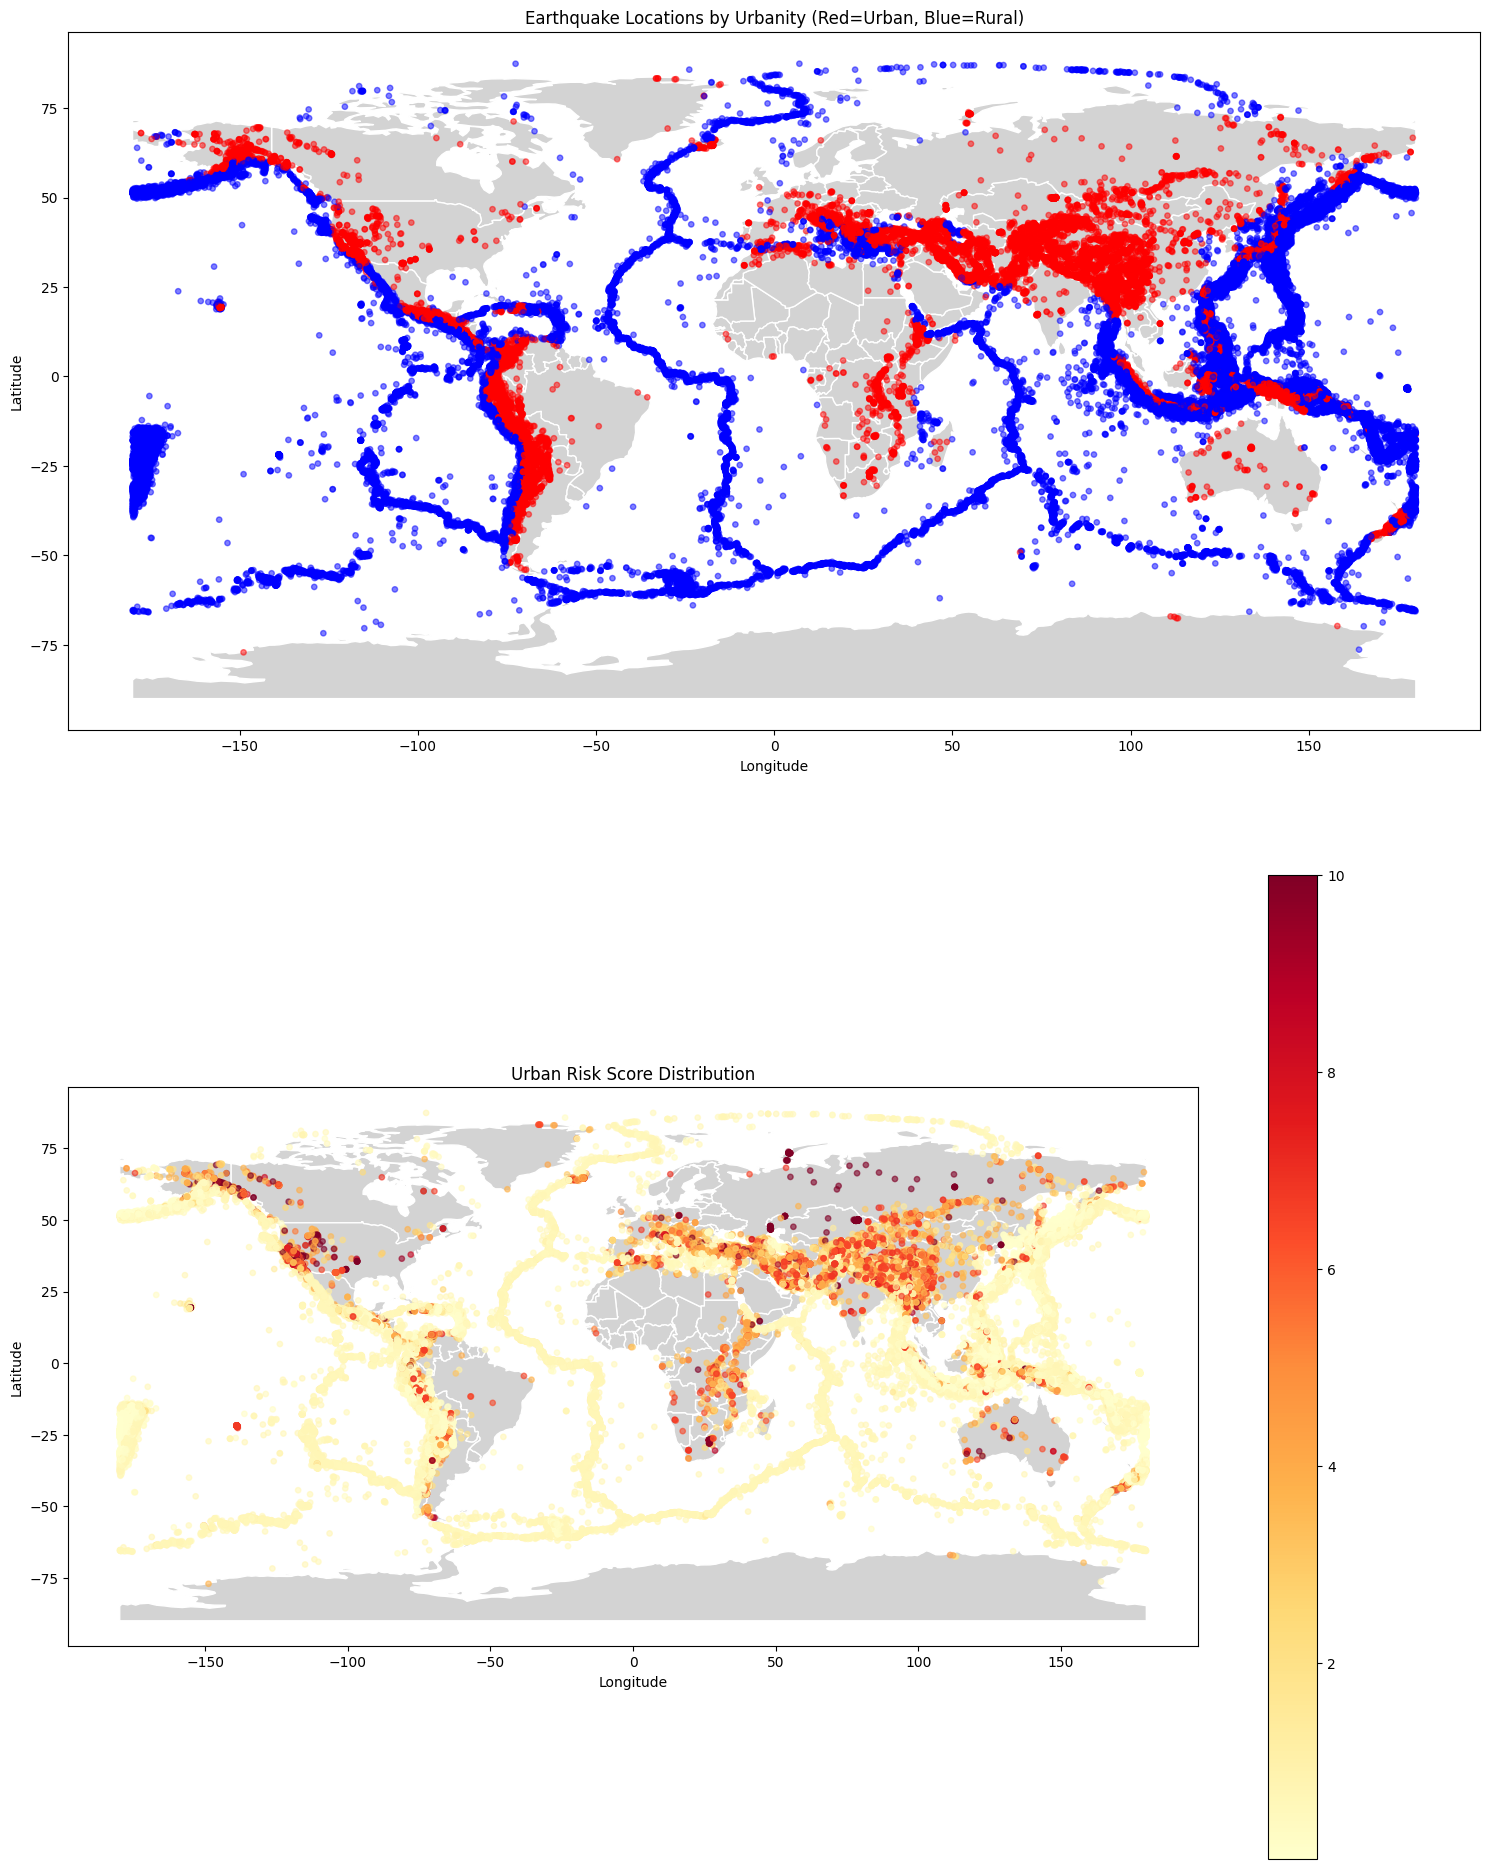

In [12]:
# Step 5: Visualization

# Plot earthquake locations colored by urbanity indicator
world = gpd.read_file('../../../shp/ne_110m_admin_0_countries.shp')

fig, axes = plt.subplots(2, 1, figsize=(15, 20))

# Plot 1: Urbanity Indicator
ax1 = axes[0]
world.plot(ax=ax1, color='lightgrey', edgecolor='white')
colors = {0: 'blue', 1: 'red'}
gdf_joined.plot(
    ax=ax1,
    marker='o',
    column='urbanity_indicator',
    color=gdf_joined['urbanity_indicator'].map(colors),
    markersize=15,
    alpha=0.5
)
ax1.set_title('Earthquake Locations by Urbanity (Red=Urban, Blue=Rural)')
ax1.set_xlabel('Longitude')
ax1.set_ylabel('Latitude')

# Plot 2: Urban Risk Score
ax2 = axes[1]
world.plot(ax=ax2, color='lightgrey', edgecolor='white')
gdf_joined.plot(
    ax=ax2,
    marker='o',
    column='risk_score',
    cmap='YlOrRd',
    markersize=15,
    alpha=0.6,
    legend=True
)
ax2.set_title('Urban Risk Score Distribution')
ax2.set_xlabel('Longitude')
ax2.set_ylabel('Latitude')

plt.tight_layout()
plt.show()


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109848 entries, 0 to 109847
Data columns (total 20 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   latitude            109848 non-null  float64
 1   longitude           109848 non-null  float64
 2   depth               109848 non-null  float64
 3   mag                 109848 non-null  float64
 4   magType             109848 non-null  object 
 5   rms                 109848 non-null  float64
 6   type                109848 non-null  object 
 7   status              109848 non-null  object 
 8   Year                109848 non-null  int64  
 9   Month               109848 non-null  int64  
 10  Day                 109848 non-null  int64  
 11  Hour                109848 non-null  int64  
 12  Minute              109848 non-null  int64  
 13  Second              109848 non-null  int64  
 14  DayOfWeek           109848 non-null  int64  
 15  Mw                  109715 non-nul

In [10]:
df.to_csv('../../../data/preprocessed_earthquake_data_v4.csv')

### Observations: